## <center>Advanced Machine Learning and Deep Learning - RL Final Project


#### <center>December 2025

## Task 1

Read the description of the game in https://gymnasium.farama.org/environments/box2d/lunar_lander/.

In [1]:
import numpy as np
import json
import time
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import random
import os
import glob
import colorsys
import ipywidgets as widgets
import multiprocessing as mp
import seaborn as sns
import pandas as pd
from collections import deque
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.patches import Patch
from pathlib import Path


In [2]:
!pip install swig
!pip install gymnasium[box2d]
!pip install moviepy pygame

import gymnasium as gym
from gymnasium.utils.save_video import save_video
from gymnasium.wrappers import RecordVideo
from IPython.display import Video

env = gym.make("LunarLander-v3")


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Sergio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Sergio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\Sergio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


**Lunar Lander Environment Overview**

The **LunarLander-v3** is task provided by the Gymnasium library.  
The objective is to safely land a spacecraft on a designated landing pad located at the center of the surface, while minimizing fuel consumption and avoiding crashes.


**Environment Dynamics**

The lander starts at a random position above the surface with an initial velocity.  

A successful landing requires:
- Touching down between the landing flags
- Maintaining a low vertical and horizontal velocity
- Keeping the lander upright

The episode terminates when:
- The lander lands successfully
- The lander crashes
- The lander moves out of bounds


**State Space**

1. **x position** of the lander  
2. **y position** of the lander  
3. **x velocity**  
4. **y velocity**  
5. **angle** of the lander  
6. **angular velocity**  
7. **left leg contact** (boolean: 1 if touching the ground, 0 otherwise)  
8. **right leg contact** (boolean: 1 if touching the ground, 0 otherwise)


**Action Space**

The action space is **discrete with 4 possible actions**:

- **0**: Do nothing  
- **1**: Fire left orientation engine  
- **2**: Fire main engine  
- **3**: Fire right orientation engine  


**Reward Function**

- Positive reward for moving closer to the landing pad
- Negative reward for high velocity and large angles
- Penalty for firing engines (fuel consumption)
- **+100 reward** for a successful landing
- **-100 penalty** for crashing

## Task 2

Try to code, as we saw in class, RL agents that play several episodes of the Lunar Lander and try to learn from previous experience. You can code:

- **i**) a total random agent;

- **ii**) an “accounting” agent (i.e., an agent that store the accumulated reward and always performs the action associated to the highest accumulated reward so far);

- **iii**) a Q-table RL agent implementing a classical ϵ-greedy policy.

Compare different behaviors with some plot and possible metrics (e.g, the
discounted accumulated reward).

In [3]:
def animate_lander_agent(agent, env_name="LunarLander-v3", video_folder="videos_accounting"):
    env = gym.make(env_name, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda ep: True, name_prefix="eval")

    state, _ = env.reset(seed=42)
    done = False
    total_reward = 0

    while not done:
        action = agent.get_next_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

    env.close()

    mp4_list = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
    if not mp4_list:
        raise RuntimeError("No video files were created.")

    print(f"Total reward during the episode: {total_reward:.2f}")

    return Video(mp4_list[-1], embed=True)

### **i)** Total Random Agent

In [4]:
class RandomAgent:
    def __init__(self, action_space):
        self.action_space = action_space

    def get_next_action(self, state):
        return self.action_space.sample()

    def update(self):
        pass # I don't care! I'm random!!

In [5]:
# Experiment parameters and agent initialization
iterations = 6000
agent = RandomAgent(env.action_space)
episode_rewards = []

In [6]:
cache = Path("cache/random_agent.npz")

if cache.exists():
    d = np.load(cache, allow_pickle=True)
    episode_rewards = d["episode_rewards"].tolist()
    logs = d["logs"].tolist()

    for msg in logs:
      print(msg)

else:
    episode_rewards = []
    logs = []

    for episode in range(iterations):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.get_next_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            state = next_state
            done = terminated or truncated

        if episode % 500 == 0:
            msg = f"Episode: {episode} completed"
            print(msg)
            logs.append(msg)

        episode_rewards.append(total_reward)

    cache.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache,
        episode_rewards=np.array(episode_rewards, dtype=np.float32),
        logs=np.array(logs, dtype=object),
    )

Episode: 0 completed
Episode: 500 completed
Episode: 1000 completed
Episode: 1500 completed
Episode: 2000 completed
Episode: 2500 completed
Episode: 3000 completed
Episode: 3500 completed
Episode: 4000 completed
Episode: 4500 completed
Episode: 5000 completed
Episode: 5500 completed


In [7]:
print(f"Average reward last 100: {np.mean(episode_rewards[-100]):.2f}")
print(f"Best reward: {np.max(episode_rewards):.2f}")
print(f"Worst reward: {np.min(episode_rewards):.2f}")

Average reward last 100: -133.14
Best reward: 74.05
Worst reward: -689.12


We begin by analyzing a **purely random agent**, which selects actions without exploiting past experience.
As expected, the average reward remains **very low**, and the agent is generally unable to achieve a
successful landing.

In the LunarLander environment, a successful landing yields a **+100 reward bonus**. Since this threshold
is never reached, the random agent clearly fails to solve the task.

However, these summary statistics alone are not sufficient to fully characterize its behavior.
As a next step, we analyze the reward evolution across episodes to confirm that, being a **random agent**,
it is **not capable of learning**.


In [8]:
episode_rewards = np.array(episode_rewards)
episodes = np.arange(len(episode_rewards))

mask = episode_rewards > 200

In [9]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=episode_rewards,mode="lines",name="Total Reward"))

fig.update_layout(
    title="Random Agent - Total Reward",
    xaxis_title="Episode",
    yaxis_title="Total Reward",
    width=800,
    height=400,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.add_trace(
    go.Scatter(
        x=episodes[mask],
        y=episode_rewards[mask],
        mode="markers",
        name="Reward > 200",
        marker=dict(color="red", size=6)
    )
)

fig.add_hline(
    y=200,
    line_dash="dash",
    line_color="black",
    annotation_text="Success threshold (200)",
    annotation_position="top left"
)

fig.show()

As expected, the random agent receives highly **variable rewards** across episodes.
The absence of any visible trend or improvement over time indicates that the **reward distribution
remains unchanged** throughout training.

This behavior confirms that the agent does not exhibit **any learning capability**, as its performance
is entirely driven by random action selection.

In [10]:
# Generate and display the animation
animate_lander_agent(agent, env_name="LunarLander-v3", video_folder="videos_random")

C:\Users\Sergio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning:

WARN: Overwriting existing videos at c:\Users\Sergio\Programs\Year 3\Advanced Machine Learning\final_project\videos_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)



Total reward during the episode: -144.31


From the simulation video, the agent’s behavior appears completely **random**, with no action consistently
preferred over the others.

### **ii)** Accounting Agent

The accounting agent maintains a cumulative reward for each action and always selects one of the actions
with the highest accumulated reward so far. After each step, the reward is added to the corresponding
action’s total.

In [11]:
import numpy as np
import random

class AccountingAgent:
    def __init__(self, action_space):
        self.action_space = action_space
        self.current_sums = np.zeros(action_space.n)
        self.history_sums = []

    def get_next_action(self, state):
        max_val = np.max(self.current_sums)
        best_actions = np.where(self.current_sums == max_val)[0]
        return np.random.choice(best_actions)

    def update(self, action, reward):
        self.current_sums[action] += reward

    def record_history(self):
        self.history_sums.append(self.current_sums.copy())

In [12]:
num_episodes = 6000
agent_acc = AccountingAgent(env.action_space)
episode_rewards_acc = []
history_acc = []

In [13]:
cache = Path(f"cache/accounting_agent.npz")

if cache.exists():
    d = np.load(cache, allow_pickle=True)
    episode_rewards_acc = d["episode_rewards_acc"].tolist()
    logs = d["logs"].tolist()
    agent_acc.current_sums = d["current_sums"].tolist()
    agent_acc.history_sums = d["history_sums"].tolist()

    for msg in logs:
      print(msg)

else:
    episode_rewards_acc = []
    logs = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent_acc.get_next_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            agent_acc.update(action, reward)

            total_reward += reward
            state = next_state
            done = terminated or truncated

        agent_acc.record_history()

        if episode % 500 == 0:
            msg = f"Episode: {episode} - Vals actions: {agent_acc.current_sums}"
            print(msg)
            logs.append(msg)

        episode_rewards_acc.append(total_reward)

    cache.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache,
        episode_rewards_acc=np.array(episode_rewards_acc, dtype=np.float32),
        logs=np.array(logs, dtype=object),
        current_sums=np.array(agent_acc.current_sums, dtype=np.float64),
        history_sums=np.array(agent_acc.history_sums, dtype=np.float64),
    )

Episode: 0 - Vals actions: [ -21.22664464  -22.09822523  -21.12541804 -116.15025714]
Episode: 500 - Vals actions: [-45012.27260796 -45007.93388269 -45018.64230664 -45105.11019978]
Episode: 1000 - Vals actions: [-88874.99624694 -88877.01247707 -88884.54987743 -88974.35520852]
Episode: 1500 - Vals actions: [-134091.31532126 -134090.46935596 -134116.47306264 -134185.02508696]
Episode: 2000 - Vals actions: [-179534.79934222 -179528.2661619  -179538.79975354 -179627.04528375]
Episode: 2500 - Vals actions: [-224160.20195914 -224070.12886086 -224064.46493794 -224061.30522942]
Episode: 3000 - Vals actions: [-267830.46951381 -267826.38513852 -267826.2911592  -267925.14184576]
Episode: 3500 - Vals actions: [-312868.98056703 -312805.63413962 -312805.93324938 -312804.39716006]
Episode: 4000 - Vals actions: [-356727.76609365 -356827.30356251 -356730.45356558 -356731.39217867]
Episode: 4500 - Vals actions: [-403124.76939806 -403212.66151215 -403118.44883661 -403113.05694755]
Episode: 5000 - Vals act

In [14]:
print(f"Average reward last 100: {np.mean(episode_rewards_acc[-100]):.2f}")
print(f"Best reward: {np.max(episode_rewards_acc):.2f}")
print(f"Worst reward: {np.min(episode_rewards_acc):.2f}")

Average reward last 100: -161.75
Best reward: 67.47
Worst reward: -734.31


In [15]:
episode_rewards_acc = np.array(episode_rewards_acc)
episodes_acc = np.arange(len(episode_rewards_acc))

mask_acc = episode_rewards_acc > 200

In [16]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=episode_rewards_acc,mode="lines",name="Total Reward"))

fig.update_layout(
    title="Accounting Agent - Total Reward",
    xaxis_title="Episode",
    yaxis_title="Total Reward",
    width=800,
    height=400,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.add_trace(
    go.Scatter(
        x=episodes_acc[mask_acc],
        y=episode_rewards_acc[mask_acc],
        mode="markers",
        name="Reward > 200",
        marker=dict(color="red", size=6)
    )
)

fig.add_hline(
    y=200,
    line_dash="dash",
    line_color="black",
    annotation_text="Success threshold (200)",
    annotation_position="top left"
)

fig.show()

As shown in the plot, the accounting agent is also unable to learn an effective policy, as no positive
trend in the total reward can be observed over time.

A more interesting next step is to analyze how the cumulative rewards associated with each action evolve
during training, in order to better understand the agent’s decision process.

In [17]:
# from google.colab import output
# output.enable_custom_widget_manager() #only for colab

In [18]:
history = np.array(agent_acc.history_sums)
y_range = [history.min() * 1.1, history.max() * 1.1]
labels = ['Do nothing', 'Left Engine', 'Main Engine', 'Right Engine']

fig = go.FigureWidget(
    data=[go.Bar(
        x=labels,
        y=history[0],
        marker_color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
        text=[f"{w:.1f}" for w in history[0]],
        textposition='auto'
    )],layout=go.Layout(title=f"Accounting Agent: Episode 0", yaxis=dict(range=y_range),height=450))

def update_plot(change):
    idx = change['new']
    weights = history[idx]
    with fig.batch_update():
        fig.data[0].y = weights
        fig.data[0].text = [f"{w:.1f}" for w in weights]
        fig.layout.title.text = f"Accounting Agent: Episode {idx}"

play = widgets.Play(value=0, min=0, max=len(history)-1, step=10, interval=50, repeat=True)

play.observe(update_plot, names='value')
display(widgets.VBox([play, fig]))

    'data': [{'marke…

**if the plot is not working rerun the cell after running all the notebook (for notebook on visual studio)** 

From the action–reward analysis, we observe that the cumulative rewards associated with the different actions
decreasing at a **very similar rate**, remaining approximately **tied over time**.

This behavior arises because the agent does **not learn a meaningful policy** and consistently receives
**negative rewards**. When one action becomes slightly worse than the others, it is no longer selected,
and the agent switches to another action, which in turn also accumulates a negative reward.

As a result, the accounting agent **cycles through all available actions**, accumulating negative rewards
without developing any preference or improving its performance.


In [19]:
# Generate and display the animation
animate_lander_agent(agent_acc, env_name="LunarLander-v3", video_folder="videos_accounting")

C:\Users\Sergio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning:

WARN: Overwriting existing videos at c:\Users\Sergio\Programs\Year 3\Advanced Machine Learning\final_project\videos_accounting folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)



Total reward during the episode: -822.59


From the simulation, we can observe that the lander tends to repeat **a single action**, namely the one
currently associated with the **highest cumulative reward**.

### **iii)** Q-table RL agent with ϵ-greedy policy.

The `LunarLander-v3` environment has a **continuous state space** consisting of 8 variables (position, velocity, angle, etc.). This means each variable can take an infinite number of decimal values.

However, a **Q-Table** is a discrete data structure (a matrix) that requires a finite number of rows and columns.

To solve this, we use **Discretization**

> **Note**: While binning makes the Q-Table possible, it involves a trade-off. Too few bins make the agent "clumsy" due to loss of precision, while too many bins make the table too large to converge efficiently since is gona find few times the same state.

In [20]:
def get_pivots(agent):
    q = agent.q_table

    angle_left_region   = q[:, :, :, :, 0:3, :, :, :]
    angle_center_region = q[:, :, :, :, 3:6, :, :, :]
    angle_right_region  = q[:, :, :, :, 6:9, :, :, :]

    left_region   = q[3:5, :, 0:4, :, :, :, :, :]
    center_region = q[5:7, :, :,  :, :, :, :, :]
    right_region  = q[7:9, :, 6:10, :, :, :, :, :]

    def mean_actions(region):
        return np.mean(region, axis=tuple(range(region.ndim - 1)))

    return {
        "pos_left":    mean_actions(left_region),
        "pos_center":  mean_actions(center_region),
        "pos_right":   mean_actions(right_region),

        "angle_left":   mean_actions(angle_left_region),
        "angle_center": mean_actions(angle_center_region),
        "angle_right":  mean_actions(angle_right_region),
    }

In [21]:
class QTableAgent:
    def __init__(self, action_space, learning_rate=0.1, discount_factor=0.99, epsilon=1.0, epsilon_decay=0.995):
        self.action_space = action_space
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_min = 0.01
        self.epsilon_decay = epsilon_decay
        self.history_q_tables = []
        self.bins = [
            np.linspace(-1.0, 1.0, 10),
            np.linspace(-1.0, 1.0, 10),
            np.linspace(-1.5, 1.5, 10),
            np.linspace(-1.5, 1.5, 10),
            np.linspace(-1.0, 1.0, 10),
            np.linspace(-1.0, 1.0, 10),
            [0.5],
            [0.5]
        ]
        shape = tuple(len(b) + 1 for b in self.bins) + (action_space.n,)
        self.q_table = np.zeros(shape)

    def discretize_state(self, state):
        discretized = []
        for i in range(len(state)):
            discretized.append(np.digitize(state[i], self.bins[i]))
        return tuple(discretized)

    def get_next_action(self, state):
        discretized_state = self.discretize_state(state)
        if np.random.rand() < self.epsilon:
            return self.action_space.sample()
        q_values = self.q_table[discretized_state]
        return np.argmax(q_values)

    def update(self, state, action, reward, next_state, done):
        discretized_state = self.discretize_state(state)
        discretized_next_state = self.discretize_state(next_state)

        best_next_q = np.max(self.q_table[discretized_next_state])
        td_target = reward + (0 if done else self.gamma * best_next_q)
        td_delta = td_target - self.q_table[discretized_state + (action,)]

        self.q_table[discretized_state + (action,)] += self.alpha * td_delta

        if done:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def record_history(self):
        self.history_q_tables.append(np.max(self.q_table, axis=-1))


In [22]:
num_episodes_q = 6000
q_agent = QTableAgent(env.action_space)
episode_rewards_q = []
history_pivots = []

In [23]:
cache = Path(f"cache/qtable_agent.npz")

if cache.exists():
    d = np.load(cache, allow_pickle=True)
    episode_rewards_q = d["episode_rewards_q"].tolist()
    logs = d["logs"].tolist()
    history_pivots = d["history_pivots"].tolist()
    q_agent.epsilon = float(d["epsilon"])
    q_agent.q_table = d["q_table"]

    for msg in logs:
      print(msg)

else:
    episode_rewards_q = []
    history_pivots = []
    logs = []

    for episode in range(num_episodes_q):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = q_agent.get_next_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            q_agent.update(state, action, reward, next_state, terminated or truncated)

            total_reward += reward
            state = next_state
            done = terminated or truncated

        if episode % 100 == 0:
            mean_last_50 = np.mean(episode_rewards_q[-50:]) if len(episode_rewards_q) >= 50 else (np.mean(episode_rewards_q) if len(episode_rewards_q) else 0.0)
            msg = (
                f"Episode: {episode} | "
                f"Epsilon: {q_agent.epsilon:.2f} | "
                f"Mean last 50: {mean_last_50:.2f}"
            )
            print(msg)
            logs.append(msg)
            history_pivots.append(get_pivots(q_agent))

        episode_rewards_q.append(total_reward)

    cache.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache,
        episode_rewards_q=np.array(episode_rewards_q, dtype=np.float32),
        logs=np.array(logs, dtype=object),
        history_pivots=np.array(history_pivots, dtype=object),
        epsilon=np.array(q_agent.epsilon, dtype=np.float32),
        q_table=q_agent.q_table
    )

Episode: 0 | Epsilon: 0.99 | Mean last 50: 0.00
Episode: 100 | Epsilon: 0.60 | Mean last 50: -165.94
Episode: 200 | Epsilon: 0.37 | Mean last 50: -139.59
Episode: 300 | Epsilon: 0.22 | Mean last 50: -117.47
Episode: 400 | Epsilon: 0.13 | Mean last 50: -147.59
Episode: 500 | Epsilon: 0.08 | Mean last 50: -111.92
Episode: 600 | Epsilon: 0.05 | Mean last 50: -123.27
Episode: 700 | Epsilon: 0.03 | Mean last 50: -158.04
Episode: 800 | Epsilon: 0.02 | Mean last 50: -110.08
Episode: 900 | Epsilon: 0.01 | Mean last 50: -116.37
Episode: 1000 | Epsilon: 0.01 | Mean last 50: -77.60
Episode: 1100 | Epsilon: 0.01 | Mean last 50: -85.92
Episode: 1200 | Epsilon: 0.01 | Mean last 50: -84.49
Episode: 1300 | Epsilon: 0.01 | Mean last 50: -87.87
Episode: 1400 | Epsilon: 0.01 | Mean last 50: -45.78
Episode: 1500 | Epsilon: 0.01 | Mean last 50: -46.44
Episode: 1600 | Epsilon: 0.01 | Mean last 50: -41.43
Episode: 1700 | Epsilon: 0.01 | Mean last 50: -25.37
Episode: 1800 | Epsilon: 0.01 | Mean last 50: 21.64

In [24]:
print(f"Average reward last 100: {np.mean(episode_rewards_q[-100]):.2f}")
print(f"Best reward: {np.max(episode_rewards_q):.2f}")
print(f"Worst reward: {np.min(episode_rewards_q):.2f}")

Average reward last 100: 234.93
Best reward: 277.49
Worst reward: -532.38


We now consider the Q-table–based agent. From the obtained results, this agent appears to achieve
**significantly better performance** compared to the previous baselines.

In [25]:
episode_rewards_q = np.array(episode_rewards_q)
episodes_q = np.arange(len(episode_rewards_q))

mask_q = episode_rewards_q > 200

In [55]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=episode_rewards_q,mode="lines",name="Total Reward"))

fig.update_layout(
    title="QTable Agent - Total Reward",
    xaxis_title="Episode",
    yaxis_title="Total Reward",
    width=800,
    height=400,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.add_trace(
    go.Scatter(
        x=episodes_q[mask_q],
        y=episode_rewards_q[mask_q],
        mode="markers",
        name="Reward > 200",
        marker=dict(color="red", size=6)
    )
)

fig.add_hline(
    y=200,
    line_dash="dash",
    line_color="black",
    annotation_text="Success threshold (200)",
    annotation_position="top left"
)

fig.show()

The plot shows that after roughly 1000 episodes the total reward starts to increase, indicating that the
agent begins to successfully land the module and receive the **+100 bonus**.

As training progresses, episodes exceeding the **success threshold of 200** become increasingly frequent,
highlighting a consistent improvement in performance.

At this stage, since we are moving from a random agent to a **Q-table agent** capable of learning, it becomes more informative to look beyond the rewards of individual episodes.  

One useful approach is to divide the episodes into **windows or bins** and compute the **mean and standard deviation** of the rewards within each window.  

The standard deviation provides insight into the learning process:  
- A **low standard deviation** can indicate two things:  
  1. The environment or agent has low randomness.  
  2. The agent is not effectively learning.  
- A **high standard deviation**, especially if accompanied by an **increasing mean reward**, suggests that the agent is actively exploring and learning, adjusting its behavior over time.  

In [27]:
window = 50
episode_rewards_array = np.array(episode_rewards_q)
num_windows = len(episode_rewards_array) // window
means = []
stds = []

for i in range(num_windows):
    batch = episode_rewards_array[i*window : (i+1)*window]
    means.append(np.mean(batch))
    stds.append(np.std(batch))

means = np.array(means)
stds = np.array(stds)
x = np.arange(num_windows) * window

In [28]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=np.concatenate([x, x[::-1]]),
    y=np.concatenate([means + stds, (means - stds)[::-1]]),
    fill='toself',
    fillcolor="rgba(238, 223, 204, 0.5)",
    line=dict(color='rgba(238, 223, 204, 0.5)'),
    hoverinfo="skip",
    showlegend=True,
    name="Std Dev"
))


fig.add_trace(go.Scatter(x=x,y=means,mode="lines+markers",name="Mean Reward"))



fig.update_layout(
    title=f"Random Agent Reward (window={window} episodes)",
    xaxis_title="Episode",
    yaxis_title="Reward",
    width=900,
    height=400,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.show()

This plot provides a clearer view of the learning process. A **positive trend** emerges after roughly
1000 episodes, indicating that the agent starts to learn an effective Q-table.

However, the mean reward never exceeds the **success threshold of 200**, suggesting that the policy is
not yet fully optimal. Only a subset of episodes, as shown by the **standard deviation band**, results
in successful landings, indicating that further improvements are still required.

Having established that the model is able to learn, we now focus on analyzing the evolution of the Q-table.
This step required careful design, as the Q-table contains **millions of possible states**, each associated
with four possible actions, making a full inspection infeasible.

The first challenge was therefore to define *what* to analyze. Through the `get_pivots` function, we extract
and store, at regular intervals, representative regions of the Q-table. These regions are selected to capture
meaningful and interpretable states, rather than attempting to analyze the entire table.

In particular, we focus on states related to the **position and motion of the lander** (left, center, right)
and on its **orientation angle** (left-tilted, upright, right-tilted). This allows us to study how the agent
associates actions with configurations.

Defining these regions was not straightforward. If the states are too specific, only a few samples are
available, while overly broad regions require averaging very different states, which can hide relevant
information. The selected partition represents a balanced compromise between clarity and reliability.

In [ ]:
def plot_q_pivots(step_idx):
    data = history_pivots[step_idx]
    episode_num = step_idx * 100

    positions = ['Pos Left', 'Pos Center', 'Pos Right','Angle Left', 'Angle Center', 'Angle Right']
    keys = ['pos_left', 'pos_center', 'pos_right','angle_left', 'angle_center', 'angle_right']

    actions = ['Do Nothing', 'Left', 'Main', 'Right']
    values = np.array([data[k] for k in keys]).T

    x = np.arange(len(positions))
    width = 0.18

    plt.figure(figsize=(14, 6))

    for i, action in enumerate(actions):
        plt.bar(x + (i - (len(actions)-1)/2) * width,values[i],width,label=action)

    plt.title(f"Q-Values (regional average) – Episode {episode_num}")
    plt.xticks(x, positions)
    plt.ylabel("Q-Value")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    all_vals = np.concatenate([np.concatenate([p[k] for k in keys]).reshape(-1)for p in history_pivots])
    plt.ylim(all_vals.min(), all_vals.max())


widgets.interact(plot_q_pivots,step_idx=widgets.IntSlider(min=0,max=len(history_pivots)-1,step=1,value=0,description='Step:'))


interactive(children=(IntSlider(value=0, description='Step:', max=59), Output()), _dom_classes=('widget-intera…

<function __main__.plot_q_pivots(step_idx)>

**This plot is animated**: using the slider in the top corner, it is possible to inspect how the
regional averages of the Q-table evolve throughout training.

By analyzing the mean Q-values across the selected cases, several interesting behaviors emerge.
Starting from the **position-based states**, when the lander is on the left and moving further left,
the worst action is consistently *doing nothing*, which is reasonable since it would cause the lander
to drift even farther from the center. In this situation, actions such as *main* and *right* thrust
are preferred, as they help counteract the drift.

A similar but symmetric behavior can be observed when the lander is on the right and moving further right:
again, *doing nothing* is the worst choice, while *main* thrust represents the most favorable action.
When the lander is close to the center, the Q-table correctly suggests *main* thrust as the best action,
which is consistent with the need to control vertical descent.

A comparable analysis can be performed for the **angle-based states**, although the effect is less evident.
This is mainly due to the fact that each bar represents an average over multiple discretized states,
which was necessary to avoid dealing with millions of individual Q-values.

Finally, an additional limitation arises for **extreme positions** of the lander. States in which the
lander is very far to the left or to the right occur less frequently during training, resulting in fewer
samples for those regions. For this reason, the analysis had to adapt to the available data and focus on
regions that are both meaningful and sufficiently populated.

In [30]:
# Generate and display the animation
animate_lander_agent(q_agent, env_name="LunarLander-v3", video_folder="videos_qtable")

C:\Users\Sergio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning:

WARN: Overwriting existing videos at c:\Users\Sergio\Programs\Year 3\Advanced Machine Learning\final_project\videos_qtable folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)



Total reward during the episode: 149.81


### **Comparison**

In [31]:
import plotly.graph_objects as go
import numpy as np

N = 100

data = [
    go.Box(y=episode_rewards[-N:], name="Random"),
    go.Box(y=episode_rewards_acc[-N:], name="Accounting"),
    go.Box(y=episode_rewards_q[-N:], name="Q-learning")
]

fig = go.Figure(data=data)

fig.update_layout(
    title=f"Distribution of Total Rewards (last {N} episodes)",
    yaxis_title="Total Reward",
    width=800,
    height=400,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.show()


The distribution shows that only the **Q-learning agent** consistently achieves positive rewards,
while the random and accounting agents remain centered on negative values.

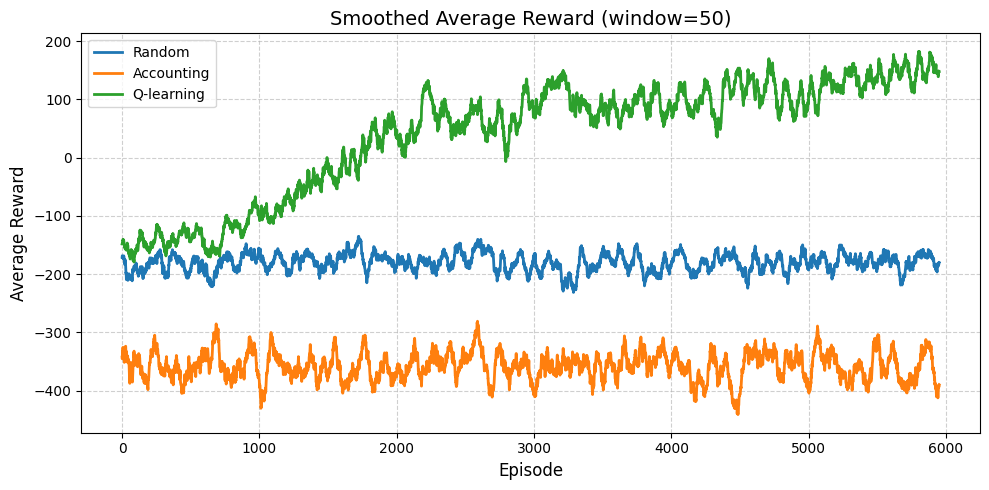

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(x, window=50):
    return np.convolve(x, np.ones(window)/window, mode="valid")

window = 50

plt.figure(figsize=(10, 5))

plt.plot(moving_average(episode_rewards, window), label="Random", linewidth=2)
plt.plot(moving_average(episode_rewards_acc, window), label="Accounting", linewidth=2)
plt.plot(moving_average(episode_rewards_q, window), label="Q-learning", linewidth=2)

plt.title(f"Smoothed Average Reward (window={window})", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Average Reward", fontsize=12)

plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The smoothed trends clearly show that only the **Q-learning agent** exhibits a positive learning curve,
while both the random and accounting agents remain stable around negative rewards, confirming their
inability to learn.

In [33]:
data = [episode_rewards, episode_rewards_acc, episode_rewards_q]
labels = ['Random', 'Accounting', 'Q-learning']
colors = ['blue', 'green', 'red']

fig = go.Figure()

for d, l, c in zip(data, labels, colors):
    fig.add_trace(go.Histogram(
        x=d,
        name=l,
        marker_color=c,
        histnorm='probability density',
        marker=dict(color='rgba(0,0,0,0)', line=dict(color=c, width=2))
    ))

fig.update_layout(
    title="Reward Distribution Comparison",
    xaxis_title="Accumulated Reward",
    yaxis_title="Density",
)
fig.show()

This plot highlights clear differences in reward distributions. The accounting agent shows a fairly uniform
distribution over **negative values**, while the random agent exhibits a single peak around **-120**.

Most interestingly, the Q-learning agent displays a **bimodal distribution**, with one peak around **-70**
and a second peak around **220**, reflecting the effect of the **+100 landing bonus** and the coexistence
of failed and successful episodes.

## Task 3

Improve the calibration of the Q-learning agent in order to obtain a good
final agent.

Training a single agent is computationally expensive, requiring approximately **3 minutes for 1000 episodes**.
Performing a full grid search over all hyperparameter combinations would therefore result in an impractical number
of training runs.

For this reason, instead of a classical grid search, we adopt a **sequential tuning approach**,
where each hyperparameter is analyzed independently while keeping the others fixed.
Although this method does not guarantee finding the globally optimal configuration,
it represents a reasonable compromise when **time and computational resources are limited**,
and still provides useful insights into the effect of each parameter on learning performance.

In [34]:
def train_mean_last50(env, agent, episodes=2000):
    last = []
    for ep in range(episodes):
        s, _ = env.reset()
        done = False
        total = 0.0
        while not done:
            a = agent.get_next_action(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            agent.update(s, a, r, ns, done)
            total += r
            s = ns
        last.append(total)
        if len(last) > 50:
            last.pop(0)
    return float(np.mean(last))

In [35]:
def plot_mean_last50_by_param(df_log, x_col, hue_col, title=None):
    df = df_log.copy()
    df["_hue"] = df[hue_col].astype(str)

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df,
        x=x_col,
        y="mean_last_50",
        hue="_hue",
        marker="o"
    )
    plt.title(title or f"Mean(last50) by {x_col}")
    plt.xlabel(x_col)
    plt.ylabel("Mean reward (last 50 episodes)")
    plt.grid(True)
    plt.legend(title=hue_col)
    plt.tight_layout()
    plt.show()

In [36]:
def _run_one_cfg(args):
    alpha, gamma, eps, eps_decay, episodes, env_id = args

    env = gym.make(env_id)
    agent = QTableAgent(env.action_space, learning_rate=alpha, discount_factor=gamma,
                        epsilon=eps, epsilon_decay=eps_decay)

    score = train_mean_last50(env, agent, episodes=episodes)
    env.close()

    print(f"[DONE] alpha={alpha} gamma={gamma} -> mean_last_50={score:.2f}",flush=True)

    return {"alpha": alpha, "gamma": gamma, "epsilon": eps, "epsilon_decay": eps_decay,
            "episodes": episodes, "mean_last_50": score}

def grid_search_q_parallel(env_id="LunarLander-v3",
                           episodes=2000,
                           lr_options=[0.05, 0.1, 0.2, 0.3],
                           gamma_options=[0.99],
                           epsilon_options=[1.0],
                           epsilon_decay_options=[0.995],
                           processes=2):

    combos = [(a, g, e, d, episodes, env_id)
              for a in lr_options
              for g in gamma_options
              for e in epsilon_options
              for d in epsilon_decay_options]

    ctx = mp.get_context("fork") # for colab
    #ctx = mp.get_context("spawn") # for visualstudio
    with ctx.Pool(processes=processes) as pool:
        rows = pool.map(_run_one_cfg, combos)

    df_log = pd.DataFrame(rows)
    best_cfg = df_log.loc[df_log["mean_last_50"].idxmax()].to_dict()
    return best_cfg, df_log

def load_obj(arr):
    obj = arr.item() if getattr(arr, "ndim", 0) == 0 else arr[0]
    return obj


### Learning Rate

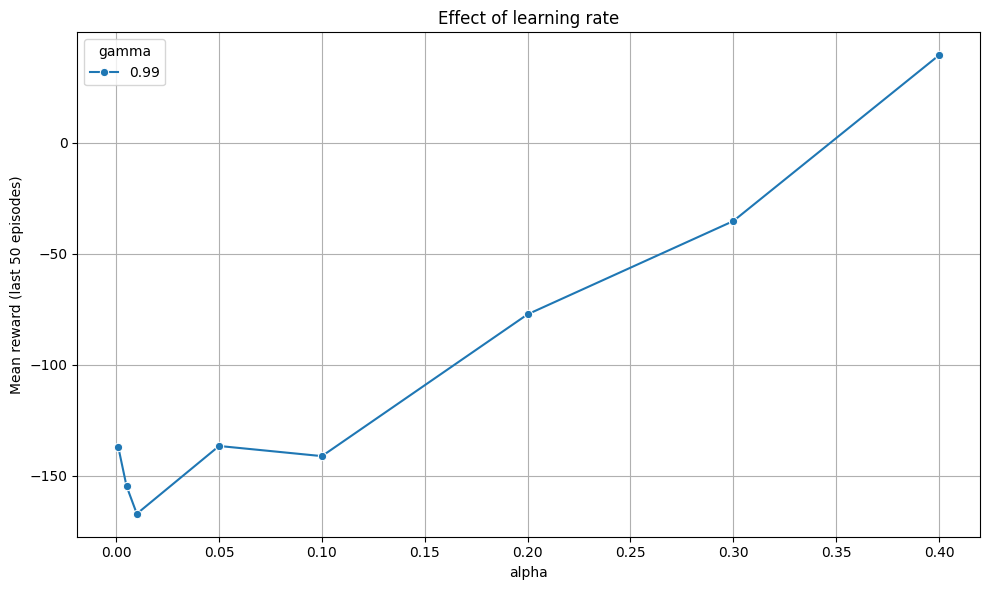

In [37]:
cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

csv_path = cache_dir / "gridsearch_learning_rate.csv"
json_path = cache_dir / "gridsearch_learning_rate_best_cfg.json"

if csv_path.exists() and json_path.exists():
    df_log = pd.read_csv(csv_path)
    with open(json_path, "r") as f:
        best_cfg = json.load(f)
else:
    best_cfg, df_log = grid_search_q_parallel(
        env_id="LunarLander-v3",
        episodes=1000,
        lr_options=[0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4],
        gamma_options=[0.99],
        epsilon_options=[1.0],
        epsilon_decay_options=[0.995],
        processes=4
    )

    df_log.to_csv(csv_path, index=False)
    with open(json_path, "w") as f:
        json.dump(best_cfg, f, indent=2)

best_cfg
plot_mean_last50_by_param(df_log, x_col="alpha", hue_col="gamma", title="Effect of learning rate")

### Discount Factor

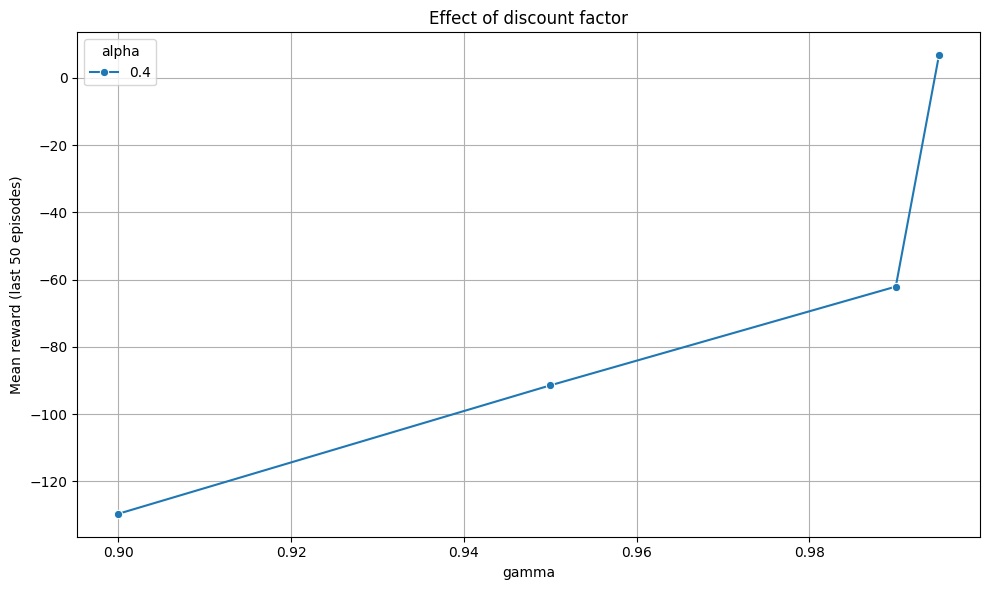

In [38]:
cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

csv_path  = cache_dir / "gridsearch_gamma.csv"
json_path = cache_dir / "gridsearch_gamma_best_cfg.json"

if csv_path.exists() and json_path.exists():
    df_log_gamma = pd.read_csv(csv_path)
    with open(json_path, "r") as f:
        best_cfg_gamma = json.load(f)
else:
    best_cfg_gamma, df_log_gamma = grid_search_q_parallel(
        env_id="LunarLander-v3",
        episodes=1000,
        lr_options=[0.4],
        gamma_options=[0.9, 0.95, 0.99, 0.995],
        epsilon_options=[1.0],
        epsilon_decay_options=[0.995],
        processes=4
    )

    df_log_gamma.to_csv(csv_path, index=False)
    with open(json_path, "w") as f:
        json.dump(best_cfg_gamma, f, indent=2)

best_cfg_gamma
plot_mean_last50_by_param(df_log_gamma, x_col="gamma", hue_col="alpha", title="Effect of discount factor")

### Epsilon

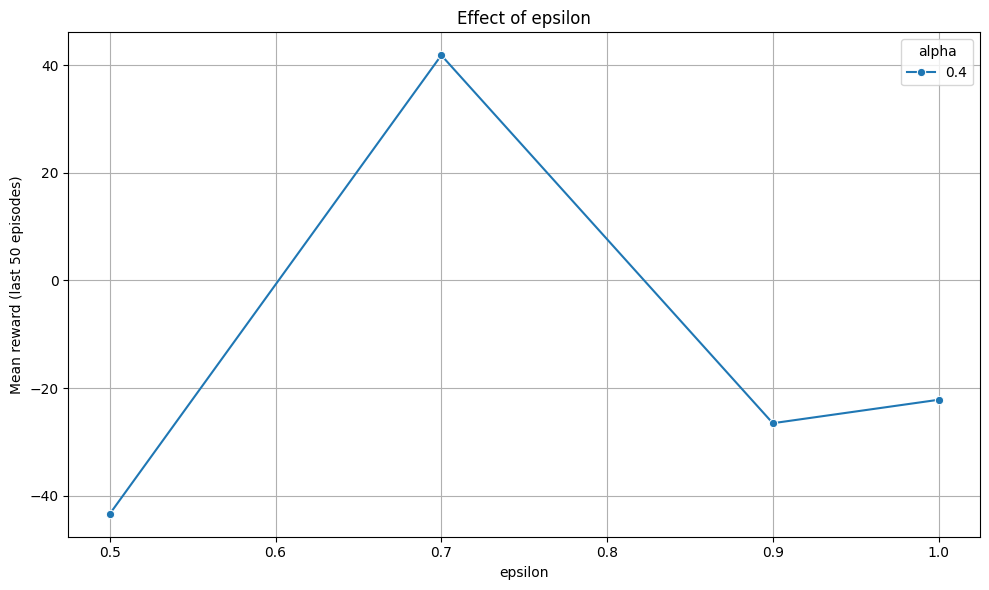

In [39]:
cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

csv_path  = cache_dir / "gridsearch_epsilon.csv"
json_path = cache_dir / "gridsearch_epsilon_best_cfg.json"

if csv_path.exists() and json_path.exists():
    df_log_eps = pd.read_csv(csv_path)
    with open(json_path, "r") as f:
        best_cfg_eps = json.load(f)
else:
    best_cfg_eps, df_log_eps = grid_search_q_parallel(
        env_id="LunarLander-v3",
        episodes=1000,
        lr_options=[0.4],
        gamma_options=[0.995],
        epsilon_options=[0.5, 0.7, 0.9, 1.0],
        epsilon_decay_options=[0.995],
        processes=4
    )

    df_log_eps.to_csv(csv_path, index=False)
    with open(json_path, "w") as f:
        json.dump(best_cfg_eps, f, indent=2)

best_cfg_eps
plot_mean_last50_by_param(df_log_eps,x_col="epsilon",hue_col="alpha",title="Effect of epsilon")

### Epsilon Decay

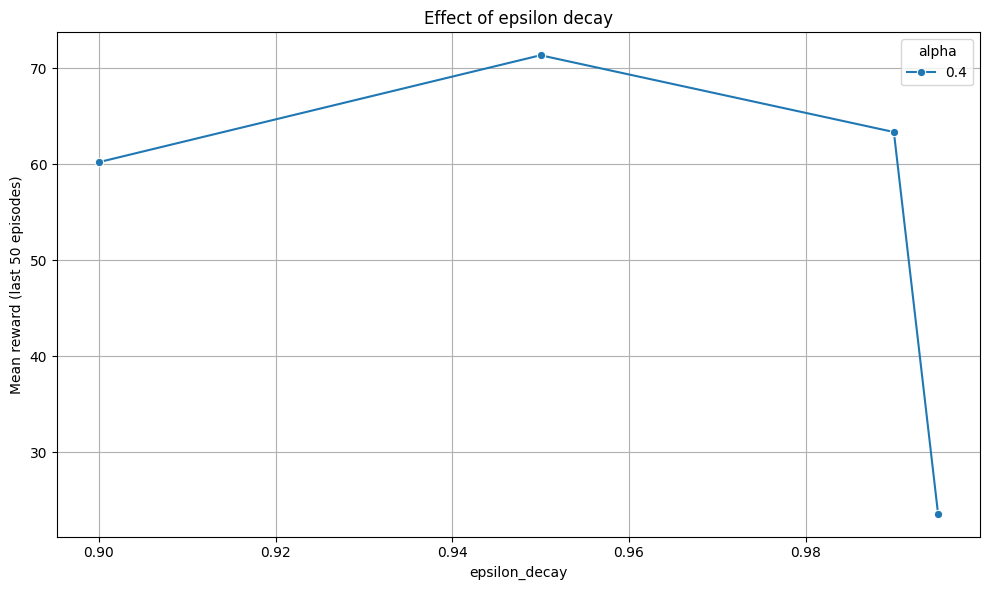

In [40]:
cache_dir = Path("cache")
cache_dir.mkdir(exist_ok=True)

csv_path  = cache_dir / "gridsearch_epsilon_decay.csv"
json_path = cache_dir / "gridsearch_epsilon_decay_best_cfg.json"

if csv_path.exists() and json_path.exists():
    df_log_decay = pd.read_csv(csv_path)
    with open(json_path, "r") as f:
        best_cfg_decay = json.load(f)
else:
    best_cfg_decay, df_log_decay = grid_search_q_parallel(
        env_id="LunarLander-v3",
        episodes=1000,
        lr_options=[0.4],
        gamma_options=[0.995],
        epsilon_options=[0.7],
        epsilon_decay_options=[0.9, 0.95, 0.99, 0.995],
        processes=4
    )

    df_log_decay.to_csv(csv_path, index=False)
    with open(json_path, "w") as f:
        json.dump(best_cfg_decay, f, indent=2)

best_cfg_decay
plot_mean_last50_by_param(df_log_decay,x_col="epsilon_decay",hue_col="alpha",title="Effect of epsilon decay")

In [41]:
num_episodes_q_final = 6000
q_agent_final = QTableAgent(env.action_space,learning_rate=0.4,discount_factor=0.995,epsilon=0.7,epsilon_decay=0.95)
episode_rewards_q_final = []
history_pivots_final = []

In [42]:
cache = Path(f"cache/qtable_final.npz")

if cache.exists():
    d = np.load(cache, allow_pickle=True)
    episode_rewards_q_final = d["episode_rewards"].tolist()
    history_pivots_final = d["history_pivots"].tolist()
    logs = d["logs"].tolist()
    q_agent_final.epsilon = float(d["epsilon"])
    q_agent_final.q_table = d["q_table"]

    for msg in logs:
      print(msg)
else:
    episode_rewards_q_final = []
    history_pivots_final = []
    logs = []

    for episode in range(num_episodes_q_final):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = q_agent_final.get_next_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            q_agent_final.update(state, action, reward, next_state, terminated or truncated)

            total_reward += reward
            state = next_state
            done = terminated or truncated

        if episode % 100 == 0:
            mean_last_50 = np.mean(episode_rewards_q_final[-50:]) if len(episode_rewards_q_final) >= 50 else (np.mean(episode_rewards_q_final) if len(episode_rewards_q_final) else 0.0)
            msg = (
                f"Episode: {episode} | "
                f"Epsilon: {q_agent_final.epsilon:.2f} | "
                f"Mean last 50: {mean_last_50:.2f}"
            )
            print(msg)
            logs.append(msg)
            history_pivots_final.append(get_pivots(q_agent_final))

        episode_rewards_q_final.append(total_reward)

    cache.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache,
        episode_rewards=np.array(episode_rewards_q_final, dtype=np.float32),
        history_pivots=np.array(history_pivots_final, dtype=object),
        logs=np.array(logs, dtype=object),
        epsilon=np.array(q_agent_final.epsilon, dtype=np.float32),
        q_table=q_agent_final.q_table
    )

Episode: 0 | Epsilon: 0.66 | Mean last 50: 0.00
Episode: 100 | Epsilon: 0.01 | Mean last 50: -162.36
Episode: 200 | Epsilon: 0.01 | Mean last 50: -118.74
Episode: 300 | Epsilon: 0.01 | Mean last 50: -103.07
Episode: 400 | Epsilon: 0.01 | Mean last 50: -79.62
Episode: 500 | Epsilon: 0.01 | Mean last 50: -11.75
Episode: 600 | Epsilon: 0.01 | Mean last 50: -31.69
Episode: 700 | Epsilon: 0.01 | Mean last 50: 38.35
Episode: 800 | Epsilon: 0.01 | Mean last 50: 3.45
Episode: 900 | Epsilon: 0.01 | Mean last 50: 6.09
Episode: 1000 | Epsilon: 0.01 | Mean last 50: 37.09
Episode: 1100 | Epsilon: 0.01 | Mean last 50: 33.07
Episode: 1200 | Epsilon: 0.01 | Mean last 50: -12.33
Episode: 1300 | Epsilon: 0.01 | Mean last 50: 62.76
Episode: 1400 | Epsilon: 0.01 | Mean last 50: 83.79
Episode: 1500 | Epsilon: 0.01 | Mean last 50: 106.30
Episode: 1600 | Epsilon: 0.01 | Mean last 50: 77.83
Episode: 1700 | Epsilon: 0.01 | Mean last 50: 50.08
Episode: 1800 | Epsilon: 0.01 | Mean last 50: 121.60
Episode: 1900 |

In [43]:
window = 50
episode_rewards_q_final = np.array(episode_rewards_q_final)
num_windows = len(episode_rewards_q_final) // window
means_f = []
stds_f = []

for i in range(num_windows):
    batch_f = episode_rewards_q_final[i*window : (i+1)*window]
    means_f.append(np.mean(batch_f))
    stds_f.append(np.std(batch_f))

means_f = np.array(means_f)
stds_f = np.array(stds_f)
x = np.arange(num_windows) * window

In [44]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=np.concatenate([x, x[::-1]]),
    y=np.concatenate([means_f + stds_f, (means_f - stds_f)[::-1]]),
    fill='toself',
    fillcolor="rgba(100, 149, 237, 0.3)",
    line=dict(color='rgba(100, 149, 237, 0.3)'),
    hoverinfo="skip",
    showlegend=True,
    name="Q-Table Final Std Dev"
))

fig.add_trace(go.Scatter(
    x=x,
    y=means_f,
    mode="lines+markers",
    name="Q-Table Final Mean",
    line=dict(color="royalblue")
))

fig.add_trace(go.Scatter(
    x=np.concatenate([x, x[::-1]]),
    y=np.concatenate([means + stds, (means - stds)[::-1]]),
    fill='toself',
    fillcolor="rgba(238, 223, 204, 0.4)",  # beige
    line=dict(color='rgba(238, 223, 204, 0.4)'),
    hoverinfo="skip",
    showlegend=True,
    name="Q-Table Std Dev"
))

fig.add_trace(go.Scatter(
    x=x,
    y=means,
    mode="lines+markers",
    name="Q-Table Mean",
    line=dict(color="saddlebrown")
))

fig.update_layout(
    title=f"Reward Comparison: Q-Table vs Q-Table Final (window={window} episodes)",
    xaxis_title="Episode",
    yaxis_title="Reward",
    width=950,
    height=420,
    margin=dict(l=50, r=50, t=50, b=50),
    legend=dict(x=0.02, y=0.98)
)

fig.show()

Comparing the initial **Q-table model** with the one obtained through **sequential hyperparameter tuning**, we do not observe a significant improvement in performance. As shown in the plot, both models reach a similar **plateau**, indicating that they have likely achieved the maximum performance attainable with this modeling approach for the given task.

This suggests that the limitation is not due to suboptimal hyperparameters, but rather to the intrinsic constraints of **tabular Q-learning with discretized states** in a continuous environment. Although further improvements could potentially be obtained by tuning the number of discretization bins, this option was not explored due to the high computational cost required.


In [45]:
# Generate and display the animation
animate_lander_agent(q_agent_final, env_name="LunarLander-v3", video_folder="videos_qtable_final")

C:\Users\Sergio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning:

WARN: Overwriting existing videos at c:\Users\Sergio\Programs\Year 3\Advanced Machine Learning\final_project\videos_qtable_final folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)



Total reward during the episode: 210.32


## Task 4

Try to implement a DQN or double-DQN RL agent for the same problem.

We now move beyond the limitations of a tabular Q-learning approach and introduce **more expressive models**, namely **Deep Q-Network (DQN)** and **Double DQN**, which are better suited for environments with continuous state spaces such as Lunar Lander.

After reading different paper about this task i saw that the model performance is often evaluated by measuring **how quickly the agent achieves an average reward greater than 200 over a sliding window of 50 episodes**. Reaching this threshold is commonly used as an indicator that the task has been successfully solved.

To keep training time reasonable and avoid unnecessary computation, we adopt the same criterion in our experiments. This allows us to **fairly compare DQN and Double DQN** based on learning speed and stability, rather than training both models for a fixed and potentially excessive number of episodes.


### DQN agent

The **DQN class** used in this section is based on the implementation provided in the **Dungeon_dqn** notebook and has been **adapted** for the Lunar Lander task.

In [46]:
class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma=0.99,
        learning_rate=1e-3,
        eps_start=1.0,
        eps_min=0.05,
        eps_decay_steps=80_000,
        batch_size=64,
        buffer_size=100_000,
        target_update_steps=1000,
        device=None
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size

        # ε-greedy schedule
        self.epsilon = eps_start
        self.eps_min = eps_min
        self.eps_delta = (eps_start - eps_min) / eps_decay_steps

        # replay buffer: (state, action, reward, next_state)
        self.buffer = deque(maxlen=buffer_size)

        # to keep compatibility with the previous agents
        self.q_table = None

        # device
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # Q-network + target network
        self.q = self._build_model().to(self.device)
        self.q_target = self._build_model().to(self.device)
        self.q_target.load_state_dict(self.q.state_dict())
        self.q_target.eval()

        self.optimizer = optim.Adam(self.q.parameters(), lr=learning_rate)
        self.loss_fn = nn.SmoothL1Loss()  # Huber

        self.steps = 0
        self.target_update_steps = target_update_steps

    def _build_model(self):
        return nn.Sequential(
            nn.Linear(self.state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, self.action_dim),
        )

    def get_next_action(self, state):
        if np.random.rand() < self.epsilon:
            # random action
            return random.randrange(self.action_dim)

        s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q(s)
        return int(torch.argmax(q_values, dim=1).item())

    def _sample(self):
        batch = random.sample(self.buffer, self.batch_size)
        s, a, r, ns, done = map(np.array, zip(*batch))
        return s, a, r, ns, done

    def _training_step(self):
        s, a, r, ns, done = self._sample()

        s = torch.tensor(s, dtype=torch.float32, device=self.device)
        ns = torch.tensor(ns, dtype=torch.float32, device=self.device)
        a = torch.tensor(a, dtype=torch.int64, device=self.device).unsqueeze(1)
        r = torch.tensor(r, dtype=torch.float32, device=self.device).unsqueeze(1)
        done = torch.tensor(done, dtype=torch.float32, device=self.device).unsqueeze(1)

        # Q(s,a)
        q_sa = self.q(s).gather(1, a)

        with torch.no_grad():
            # target = r + γ max_a' Q_target(s',a')
            next_q = self.q_target(ns).max(dim=1, keepdim=True)[0]
            target = r + (1.0 - done) * self.gamma * next_q

        loss = self.loss_fn(q_sa, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q.parameters(), 10.0)
        self.optimizer.step()

        return float(loss.item())

    def update(self, old_state, new_state, action, reward, done):
        self.buffer.append((old_state, action, reward, new_state, done))

        if self.epsilon > self.eps_min:
            self.epsilon = max(self.eps_min, self.epsilon - self.eps_delta)

        loss = None
        if len(self.buffer) >= self.batch_size:
            loss = self._training_step()

        self.steps += 1
        if self.steps % self.target_update_steps == 0:
            self.q_target.load_state_dict(self.q.state_dict())

        return loss


In [47]:
env = gym.make("LunarLander-v3")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent_DQNA = DQNAgent(state_dim, action_dim)

max_episodes = 2000
cache = Path(f"cache/dqn_agent.npz")
weights_path = Path("cache/dqn_weights.pth")

if cache.exists():
    d = np.load(cache, allow_pickle=True)
    episode_rewards = d["episode_rewards"].tolist()
    logs = d["logs"].tolist()
    agent_DQNA.epsilon = float(d["epsilon"])

    if weights_path.exists():
        agent_DQNA.q.load_state_dict(torch.load(weights_path))
        agent_DQNA.q_target.load_state_dict(agent_DQNA.q.state_dict())

    for msg in logs:
      print(msg)

else:
    episode_rewards = []
    logs = []

    for ep in range(max_episodes):
        s, _ = env.reset()
        done = False
        total = 0.0

        while not done:
            a = agent_DQNA.get_next_action(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc

            agent_DQNA.update(s, ns, a, r, done)

            total += r
            s = ns

        episode_rewards.append(total)

        mean50 = np.mean(episode_rewards[-50:]) if len(episode_rewards) >= 50 else np.mean(episode_rewards)

        if ep % 50 == 0:
            msg = f"Ep {ep} | mean_last_50={mean50:.2f} | eps={agent_DQNA.epsilon:.3f}"
            print(msg)
            logs.append(msg)

        if mean50 > 200:
            msg = f"Ep {ep} | mean_last_50={mean50:.2f} | eps={agent_DQNA.epsilon:.3f}"
            print(msg)
            logs.append(msg)
            msg = "Task Completed, the mean of the reward is more then 200!!"
            print(msg)
            logs.append(msg)
            break

    cache.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache,
        episode_rewards=np.array(episode_rewards, dtype=np.float32),
        logs=np.array(logs, dtype=object),
        epsilon=np.array(agent_DQNA.epsilon, dtype=np.float32),
    )
    torch.save(agent_DQNA.q.state_dict(), weights_path)

Ep 0 | mean_last_50=-58.23 | eps=0.999
Ep 50 | mean_last_50=-149.54 | eps=0.933
Ep 100 | mean_last_50=-120.29 | eps=0.876
Ep 150 | mean_last_50=-102.92 | eps=0.819
Ep 200 | mean_last_50=-89.20 | eps=0.760
Ep 250 | mean_last_50=-72.08 | eps=0.695
Ep 300 | mean_last_50=-58.83 | eps=0.629
Ep 350 | mean_last_50=-37.80 | eps=0.564
Ep 400 | mean_last_50=-36.22 | eps=0.482
Ep 450 | mean_last_50=-25.98 | eps=0.401
Ep 500 | mean_last_50=5.84 | eps=0.050
Ep 543 | mean_last_50=202.46 | eps=0.050
Task Completed, the mean of the reward is more then 200!!


In [48]:
# Generate and display the animation
animate_lander_agent(agent_DQNA, env_name="LunarLander-v3", video_folder="videos_DQNA")

C:\Users\Sergio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning:

WARN: Overwriting existing videos at c:\Users\Sergio\Programs\Year 3\Advanced Machine Learning\final_project\videos_DQNA folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)



Total reward during the episode: 145.23


### Double DQN Agent

In [49]:
from collections import deque
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim


class DoubleDQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma=0.99,
        learning_rate=1e-3,
        eps_start=1.0,
        eps_min=0.05,
        eps_decay_steps=80_000,
        batch_size=64,
        buffer_size=100_000,
        target_update_steps=1000,
        device=None
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size

        # ε-greedy schedule
        self.epsilon = eps_start
        self.eps_min = eps_min
        self.eps_delta = (eps_start - eps_min) / eps_decay_steps

        # replay buffer
        self.buffer = deque(maxlen=buffer_size)

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # Q-network + target network
        self.q = self._build_model().to(self.device)
        self.q_target = self._build_model().to(self.device)
        self.q_target.load_state_dict(self.q.state_dict())
        self.q_target.eval()

        self.optimizer = optim.Adam(self.q.parameters(), lr=learning_rate)
        self.loss_fn = nn.SmoothL1Loss()  # Huber

        self.steps = 0
        self.target_update_steps = target_update_steps

    def _build_model(self):
        return nn.Sequential(
            nn.Linear(self.state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, self.action_dim),
        )

    def get_next_action(self, state):
        if np.random.rand() < self.epsilon:
            return random.randrange(self.action_dim)

        s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q(s)
        return int(torch.argmax(q_values, dim=1).item())

    def _sample(self):
        batch = random.sample(self.buffer, self.batch_size)
        s, a, r, ns, done = map(np.array, zip(*batch))
        return s, a, r, ns, done

    def _training_step(self):
        s, a, r, ns, done = self._sample()

        s = torch.tensor(s, dtype=torch.float32, device=self.device)
        ns = torch.tensor(ns, dtype=torch.float32, device=self.device)
        a = torch.tensor(a, dtype=torch.int64, device=self.device).unsqueeze(1)
        r = torch.tensor(r, dtype=torch.float32, device=self.device).unsqueeze(1)
        done = torch.tensor(done, dtype=torch.float32, device=self.device).unsqueeze(1)

        # Q(s,a)
        q_sa = self.q(s).gather(1, a)

        with torch.no_grad():
            # Double DQN:
            # a* = argmax_a Q(s',a)  (online network)
            next_actions = self.q(ns).argmax(dim=1, keepdim=True)
            # Q_target(s', a*)       (target network)
            next_q = self.q_target(ns).gather(1, next_actions)
            target = r + (1.0 - done) * self.gamma * next_q

        loss = self.loss_fn(q_sa, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q.parameters(), 10.0)
        self.optimizer.step()

        return float(loss.item())

    def update(self, old_state, new_state, action, reward, done):
        self.buffer.append((old_state, action, reward, new_state, done))

        if self.epsilon > self.eps_min:
            self.epsilon = max(self.eps_min, self.epsilon - self.eps_delta)

        loss = None
        if len(self.buffer) >= self.batch_size:
            loss = self._training_step()

        self.steps += 1
        if self.steps % self.target_update_steps == 0:
            self.q_target.load_state_dict(self.q.state_dict())

        return loss


In [50]:
env = gym.make("LunarLander-v3")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent_Ddqn = DoubleDQNAgent(state_dim, action_dim)

max_episodes = 2000
cache = Path(f"cache/ddqn_agent.npz")
weights_path = Path("cache/ddqn_weights.pth")

if cache.exists():
    d = np.load(cache, allow_pickle=True)
    episode_rewards_Ddqn = d["episode_rewards"].tolist()
    logs = d["logs"].tolist()
    agent_Ddqn.epsilon = float(d["epsilon"])

    if weights_path.exists():
            agent_Ddqn.q.load_state_dict(torch.load(weights_path))
            agent_Ddqn.q_target.load_state_dict(agent_Ddqn.q.state_dict())

    for msg in logs:
      print(msg)

else:
    episode_rewards_Ddqn = []
    logs = []

    for ep in range(max_episodes):
        s, _ = env.reset()
        done = False
        total = 0.0

        while not done:
            a = agent_Ddqn.get_next_action(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc

            agent_Ddqn.update(s, ns, a, r, done)

            total += r
            s = ns

        episode_rewards_Ddqn.append(total)

        mean50 = np.mean(episode_rewards_Ddqn[-50:]) if len(episode_rewards_Ddqn) >= 50 else np.mean(episode_rewards_Ddqn)

        if ep % 50 == 0:
            msg = f"Ep {ep} | mean_last_50={mean50:.2f} | eps={agent_Ddqn.epsilon:.3f}"
            print(msg)
            logs.append(msg)

        if mean50 > 200:
            msg = f"Ep {ep} | mean_last_50={mean50:.2f} | eps={agent_Ddqn.epsilon:.3f}"
            print(msg)
            logs.append(msg)
            msg = "Task Completed, the mean of the reward is more than 200!!"
            print(msg)
            logs.append(msg)
            break

    cache.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache,
        episode_rewards=np.array(episode_rewards_Ddqn, dtype=np.float32),
        logs=np.array(logs, dtype=object),
        epsilon=np.array(agent_Ddqn.epsilon, dtype=np.float32),
    )
    torch.save(agent_Ddqn.q.state_dict(), weights_path)

Ep 0 | mean_last_50=-98.11 | eps=0.999
Ep 50 | mean_last_50=-164.74 | eps=0.942
Ep 100 | mean_last_50=-149.11 | eps=0.883
Ep 150 | mean_last_50=-105.30 | eps=0.825
Ep 200 | mean_last_50=-80.72 | eps=0.766
Ep 250 | mean_last_50=-74.99 | eps=0.701
Ep 300 | mean_last_50=-68.69 | eps=0.637
Ep 350 | mean_last_50=-48.45 | eps=0.573
Ep 400 | mean_last_50=-32.75 | eps=0.488
Ep 450 | mean_last_50=-34.17 | eps=0.380
Ep 500 | mean_last_50=-14.60 | eps=0.050
Ep 550 | mean_last_50=134.91 | eps=0.050
Ep 600 | mean_last_50=136.59 | eps=0.050
Ep 623 | mean_last_50=201.63 | eps=0.050
Task Completed, the mean of the reward is more than 200!!


In [51]:
# Generate and display the animation
animate_lander_agent(agent_Ddqn, env_name="LunarLander-v3", video_folder="videos_DDQNA")

C:\Users\Sergio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning:

WARN: Overwriting existing videos at c:\Users\Sergio\Programs\Year 3\Advanced Machine Learning\final_project\videos_DDQNA folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)



Total reward during the episode: 223.11


## Conclusion

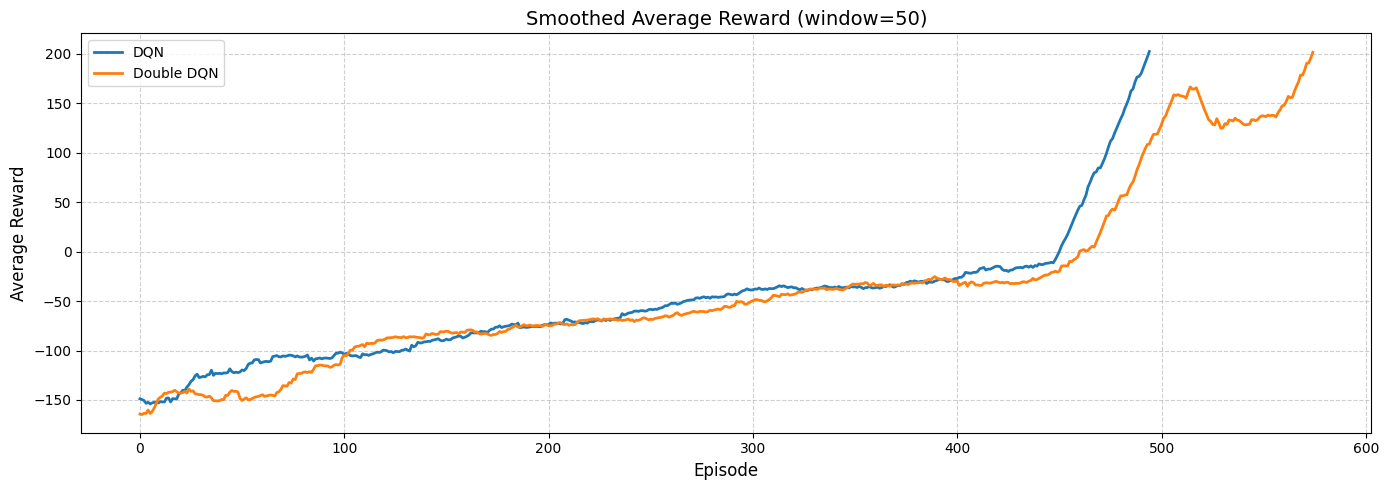

In [52]:
plt.figure(figsize=(14, 5))

plt.plot(moving_average(episode_rewards, 50), label="DQN", linewidth=2)
plt.plot(moving_average(episode_rewards_Ddqn, 50), label="Double DQN", linewidth=2)

plt.title(f"Smoothed Average Reward (window={50})", fontsize=14)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Average Reward", fontsize=12)

plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

From the plot we can observe that **both DQN and Double DQN significantly outperform the previous tabular Q-learning approaches**, achieving substantially higher rewards and successfully solving the Lunar Lander task. In both cases, the agents reach a **smoothed average reward above 200 (window = 50)**, which is used as the criterion for considering the task solved.

Comparing the two deep reinforcement learning methods, their overall learning behavior is similar in the early stages, with both agents exhibiting slow and unstable progress during the first few hundred episodes.

This behavior is consistent with the theoretical motivation behind Double DQN, which aims to reduce overestimation bias in Q-value updates.

In [53]:
STATE_DIMS = {"x": 0, "y": 1, "vx": 2, "vy": 3,"angle": 4, "ang_vel": 5, "left_leg": 6, "right_leg": 7}
RANGES = {"x": (-1.0, 1.0),"y": (0.0, 1.5),"vx": (-2.0, 2.0),"vy": (-2.0, 2.0),"angle": (-1.0, 1.0),"ang_vel": (-2.0, 2.0),"left_leg": (0.0, 1.0),"right_leg": (0.0, 1.0),}
ACTION_NAMES = ["Do nothing", "Right", "Main", "Left"]
cmap = ListedColormap(plt.cm.tab10.colors[:4])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

In [ ]:
def action_map_2d(agent, x_name, y_name, nx=81, ny=61):
    xs = np.linspace(*RANGES[x_name], nx)
    ys = np.linspace(*RANGES[y_name], ny)
    X, Y = np.meshgrid(xs, ys)

    s = np.zeros((X.size, 8), dtype=np.float32)
    s[:, STATE_DIMS[x_name]] = X.ravel()
    s[:, STATE_DIMS[y_name]] = Y.ravel()

    with torch.no_grad():
        q = agent.q(torch.tensor(s, dtype=torch.float32, device=agent.device))
        a = q.argmax(1).cpu().numpy().reshape(Y.shape)

    return xs, ys, a

def plot_policy_maps_xy(x_name="x", y_name="y"):
    xs, ys, A_dqn  = action_map_2d(agent_DQNA, x_name, y_name)
    l,  l,  A_ddqn = action_map_2d(agent_Ddqn, x_name, y_name)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    ax[0].imshow(A_dqn, origin="lower",extent=[xs.min(), xs.max(), ys.min(), ys.max()],cmap=cmap, norm=norm, aspect="auto")
    ax[0].set_title(f"Single DQN — {x_name} vs {y_name}")
    ax[0].set_xlabel(x_name)
    ax[0].set_ylabel(y_name)

    ax[1].imshow(A_ddqn, origin="lower",extent=[xs.min(), xs.max(), ys.min(), ys.max()],cmap=cmap, norm=norm, aspect="auto")
    ax[1].set_title(f"Double DQN — {x_name} vs {y_name}")
    ax[1].set_xlabel(x_name)

    handles = [Patch(facecolor=cmap(i), edgecolor="k", label=ACTION_NAMES[i]) for i in range(4)]
    fig.legend(handles=handles, loc="upper center", ncol=4, frameon=True, fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

widgets.interact(
    plot_policy_maps_xy,
    x_name=widgets.Dropdown(options=list(STATE_DIMS.keys()), value="x", description="X:"),
    y_name=widgets.Dropdown(options=list(STATE_DIMS.keys()), value="y", description="Y:")
)

interactive(children=(Dropdown(description='X:', options=('x', 'y', 'vx', 'vy', 'angle', 'ang_vel', 'left_leg'…

<function __main__.plot_policy_maps_xy(x_name='x', y_name='y')>

To conclude, an analysis of the learned policies for both models was performed in order to identify patterns and similarities in their behavior. A key limitation of this analysis is that the resulting policy maps may vary slightly across different runs, as the learned policies depend on stochastic training dynamics and random initialization.

Despite this variability, several consistent behaviors can be observed. In particular, analyzing the policy maps by comparing the **x** and **y** state variables reveals that both DQN and Double DQN tend to act in a very similar manner when the lander is positioned either to the left or to the right of the landing pad. In these regions, the selected actions are largely consistent across the two models.

An especially interesting case arises when comparing the **vertical position (y-axis)** with the **angular velocity (x-axis)**. In this scenario, the policy maps highlight how both models handle stabilization: when the lander exhibits a high angular velocity toward the left, both agents predominantly select the **right** action in order to counteract the rotation and stabilize the lander. A symmetric behavior can be observed for high angular velocity toward the right, where the **left** action is favored.

## Appendix – Notes on Sources and Implementation

For the development of this project, several research papers and reference implementations were studied in order to compare different models and approaches in reinforcement learning.

In particular, the following sources were consulted:

- *On the Stability and Convergence of Deep Q-Learning*  
  https://arxiv.org/pdf/2011.11850

- Julian Kappler, *Lunar Lander Reinforcement Learning Implementation*  
  https://github.com/juliankappler/lunar-lander

- *Reinforcement Learning for Lunar Lander Control* (Stanford University, AA228)  
  https://web.stanford.edu/class/aa228/reports/2019/final8.pdf

Regarding the implementation of a caching mechanism to enable fast execution of the notebook and avoid repeated expensive computations, ChatGPT was used as a supporting tool to design and structure an efficient caching strategy.

Concerning data visualization, several plots and interactive components were inspired by official documentation and examples from the following sources:

- Plotly Python Documentation  
  https://plotly.com/python/

- ipywidgets Documentation  
  https://ipywidgets.readthedocs.io/en/stable/

- ipywidgets Widget Reference – `Play`  
  https://ipywidgets.readthedocs.io/en/latest/reference/ipywidgets.html#ipywidgets.widgets.widget_int.Play
